In [12]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# 1. Загрузите изображение в оттенках серого sar_1_gray.jpg.

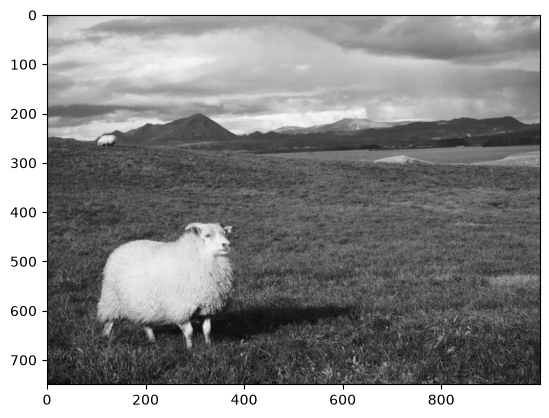

In [13]:
image_gray = cv2.imread('sar_1_gray.jpg', cv2.IMREAD_GRAYSCALE)
plt.imshow(image_gray, cmap='gray')

plt.show()

# 2. постройте гистограмму

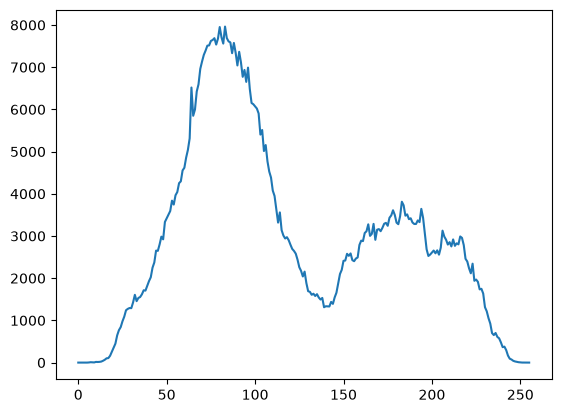

In [16]:
histSize = 256
histRange = (0, 256)
accumulate = False

hist = cv2.calcHist([image_gray], [0], None, [histSize], histRange, accumulate=accumulate)
plt.plot(hist)

plt.show()

# 3. реализуйте алгоритм гамма коррекции с параметром гамма <1, >1.

In [19]:
def gamma_correction(image, gamma):
    R_max = 255

    table = np.array([
        ((i / R_max) ** gamma) * R_max
        for i in np.arange(0, 256)
    ]).astype("uint8")

    return cv2.LUT(image, table)

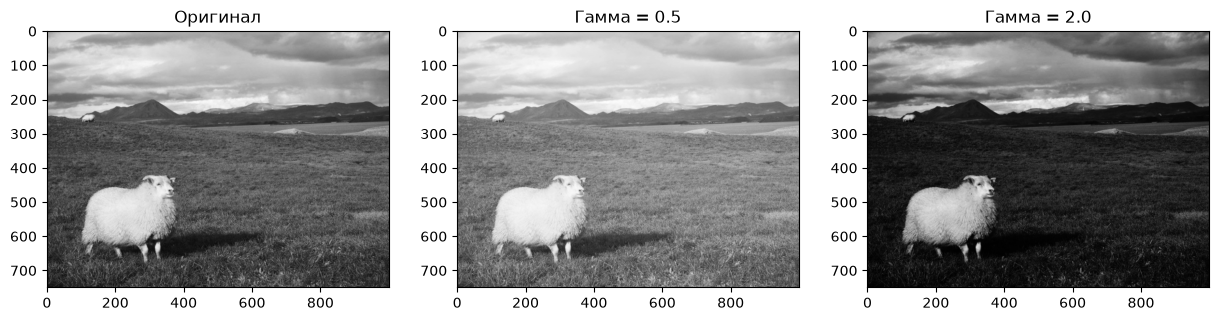

In [23]:
# гамма < 1
amma_light = gamma_correction(image_gray, 0.5)
# гамма > 1
gamma_dark = gamma_correction(image_gray, 2.0)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image_gray, cmap='gray')
axes[0].set_title('Оригинал')

axes[1].imshow(gamma_light, cmap='gray')
axes[1].set_title('Гамма = 0.5')

axes[2].imshow(gamma_dark, cmap='gray')
axes[2].set_title('Гамма = 2.0')

plt.show()

# 4. Сравните исходное изображение, скорректированное при помощи гамма-фильтра. MSE, SSIM.

Гамма 0.5
MSE  = 2738.48
SSIM = 0.8795


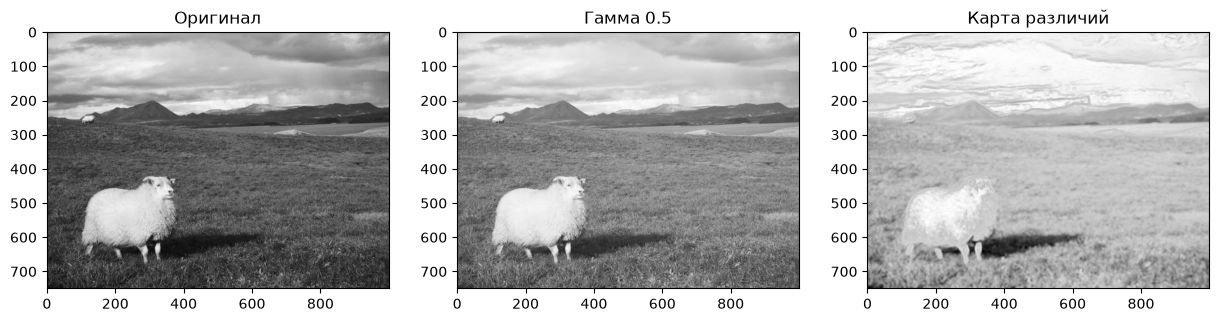

In [51]:
mse = mean_squared_error(image_gray, img_gamma_light)
ssim, diff = structural_similarity(image_gray, img_gamma_light, data_range=255, full=True)
diff = (diff * 255).astype("uint8")

print("Гамма 0.5")
print(f"MSE  = {mse:.2f}")
print(f"SSIM = {ssim:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(image_gray, cmap='gray')
axes[0].set_title('Оригинал')
axes[1].imshow(img_gamma_light, cmap='gray')
axes[1].set_title("Гамма 0.5")
axes[2].imshow(diff, cmap='gray')
axes[2].set_title('Карта различий')
    
plt.show()

Гамма 2.0
MSE  = 2794.14
SSIM = 0.6745


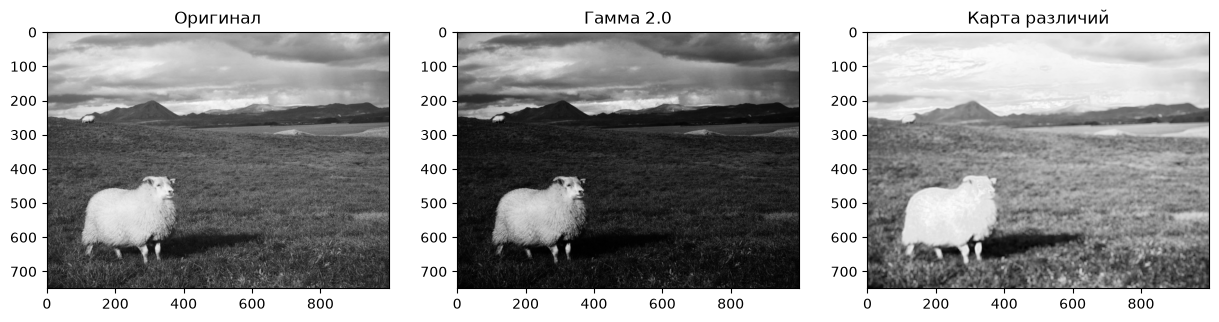

In [50]:
mse = mean_squared_error(image_gray, img_gamma_dark)
ssim, diff = structural_similarity(image_gray, img_gamma_dark, data_range=255, full=True)
diff = (diff * 255).astype("uint8")

print("Гамма 2.0")
print(f"MSE  = {mse:.2f}")
print(f"SSIM = {ssim:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(image_gray, cmap='gray')
axes[0].set_title('Оригинал')
axes[1].imshow(img_gamma_dark, cmap='gray')
axes[1].set_title("Гамма 2.0")
axes[2].imshow(diff, cmap='gray')
axes[2].set_title('Карта различий')
    
plt.show()

# 5. реализуйте алгоритм статистической цветокоррекции на основе статистики eq_gray.

In [64]:
eq_gray = cv2.equalizeHist(image_gray)
cv2.imwrite('eq_gray.jpg', eq_gray)
eq_gray = cv2.imread('eq_gray.jpg', cv2.IMREAD_GRAYSCALE)

In [65]:
E_s = eq_gray.mean()# mean эталона
D_s = eq_gray.std()# std эталона

E_t = image_gray.mean()# mean исходной картинки
D_t = image_gray.std()# std исходной картинки

In [66]:
def stat_correction(C_t, E_s, D_s):
    C_t = C_t.astype(np.float64)

    E_t = C_t.mean()
    D_t = C_t.std()

    C_t_new = E_s + (C_t - E_t) * (D_s / D_t)

    return np.clip(C_t_new, 0, 255).astype(np.uint8)

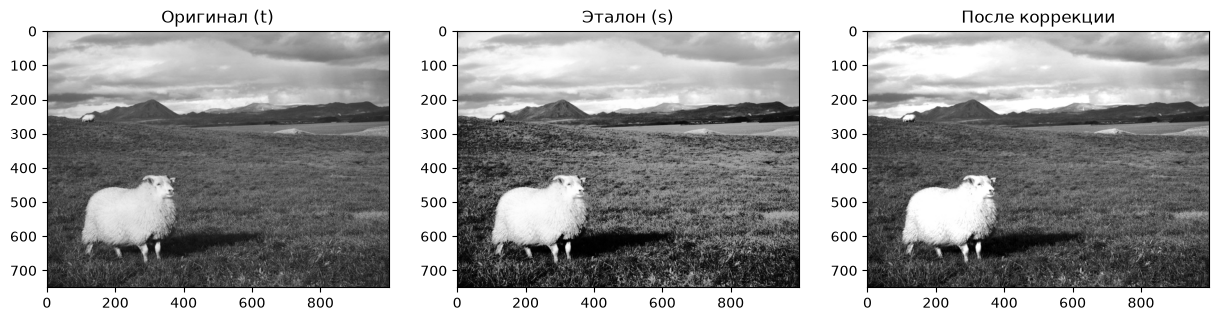

Оригинал: E_t = 118.22, D_t = 55.63
Эталон: E_s = 128.25, D_s = 73.46
После коррекции: E = 127.02, D = 72.04


In [67]:
img_stat = stat_correction(image_gray, E_s, D_s)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image_gray, cmap='gray')
axes[0].set_title('Оригинал (t)')
axes[1].imshow(eq_gray, cmap='gray')
axes[1].set_title('Эталон (s)')
axes[2].imshow(img_stat, cmap='gray')
axes[2].set_title('После коррекции')

plt.show()

print(f"Оригинал: E_t = {E_t:.2f}, D_t = {D_t:.2f}")
print(f"Эталон: E_s = {E_s:.2f}, D_s = {D_s:.2f}")
print(f"После коррекции: E = {img_stat.mean():.2f}, D = {img_stat.std():.2f}")

# 6. Протестируйте работу алгоритмов пороговой фильтрации с различными параметрами.

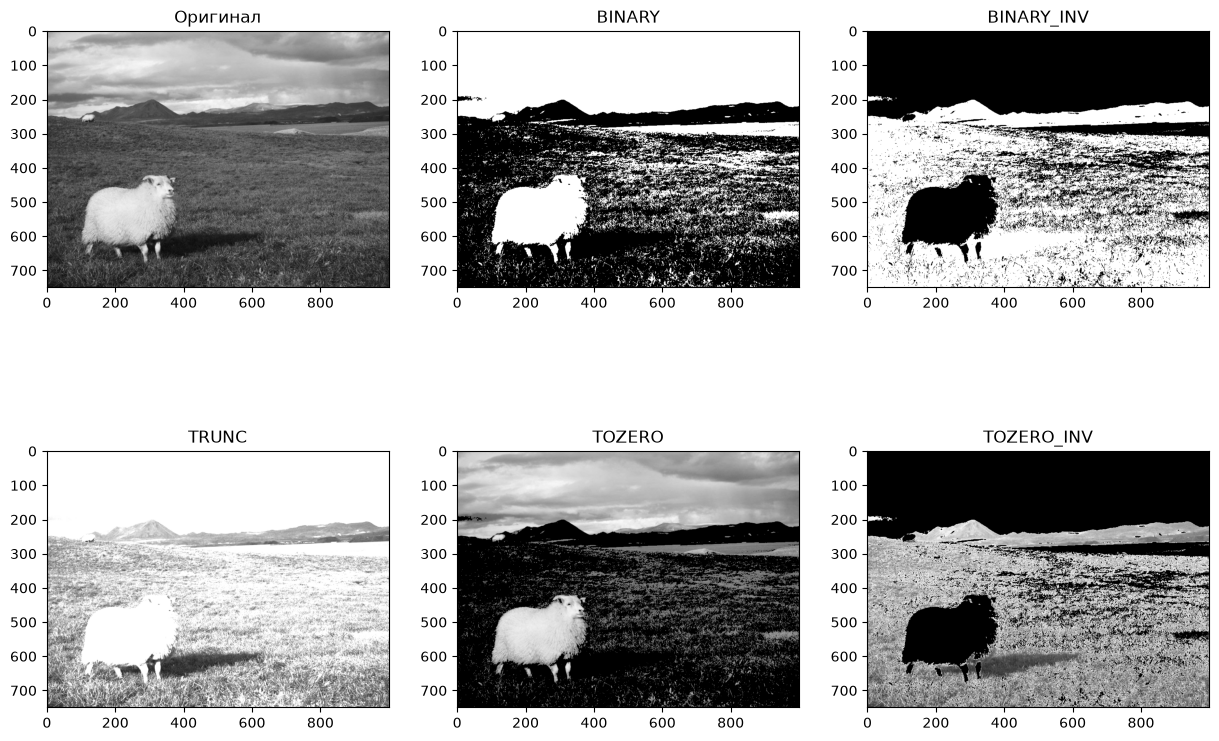

In [71]:
thresh_value = 100
max_val = 255

_, img_binary = cv2.threshold(image_gray, thresh_value, max_val, cv2.THRESH_BINARY)
_, img_binary_inv = cv2.threshold(image_gray, thresh_value, max_val, cv2.THRESH_BINARY_INV)
_, img_trunc = cv2.threshold(image_gray, thresh_value, max_val, cv2.THRESH_TRUNC)
_, img_tozero = cv2.threshold(image_gray, thresh_value, max_val, cv2.THRESH_TOZERO)
_, img_tozero_inv = cv2.threshold(image_gray, thresh_value, max_val, cv2.THRESH_TOZERO_INV)

titles = ['Оригинал', 'BINARY', 'BINARY_INV', 'TRUNC', 'TOZERO', 'TOZERO_INV']
images = [image_gray, img_binary, img_binary_inv, img_trunc, img_tozero, img_tozero_inv]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, title, im in zip(axes.ravel(), titles, images):
    ax.imshow(im, cmap='gray')
    ax.set_title(title)

plt.show()